# The existing problem (why anyone should care)

Nepal's economy depends heavily on remittances — money sent home by roughly a tenth or more of its population working abroad — and that inflow is a huge part of what keeps the country's foreign exchange reserves, banking system liquidity, and import capacity functioning. Right now:

1. Banks and policymakers see remittance figures only after the fact, in monthly reports, with no forward-looking estimate.

2. Remittance inflows fluctuate meaningfully month to month (seasonal spikes around festivals like Dashain/Tihar, sensitivity to global labor markets, exchange rate shifts, and shocks like COVID or the 2022 forex crisis).
3. Without a forecast, a bank's treasury/ALM desk and NRB's own reserve management are reacting to numbers instead of planning around them — decisions about how much a bank can lend (tied to the CD ratio, which is tied to deposits, which remittances feed) are made with a lag.
4. On top of that, the data itself isn't even in a usable form (the mess we just spent this whole conversation fixing) — so today, nobody outside NRB's own internal systems can easily build a forecast from public data at all.

# The solution

An end-to-end forecasting pipeline with two halves:

1. Data engineering : turn NRB's fragmented, cumulative, cross-tab report data into one clean, validated, 25-year monthly time series — the part we just finished and verified.

2. Modeling : build and compare forecasting models (starting with classical time-series methods — seasonal naive, ARIMA/SARIMA — then benchmarking against ML approaches with lag/seasonal features) to produce a month-ahead (and ideally few-months-ahead) remittance inflow forecast, with honest uncertainty bounds, not just a single point number.

# The real-world impact

1. For a bank: a forward estimate of incoming remittances feeds directly into deposit growth expectations, which feeds into how much the bank can safely lend without breaching regulatory liquidity ratios — turning a reactive monthly report into a planning input.

2. For NRB/macro policy: better visibility into expected forex inflows supports reserve management and import/exchange-rate stability decisions.
3. For your portfolio specifically: this project demonstrates the full chain a real data scientist is actually hired for — recognizing that "the data" isn't handed to you clean, building and validating a pipeline from genuinely messy institutional sources, and then producing a forecast with an honest, defensible business rationale attached. That's a stronger, more complete story than a model trained on a pre-cleaned dataset.

# Limitation 
1. 304 monthly observations span multiple structural breaks (COVID-19, the 2022 forex crisis, evolving labor migration patterns). This model is best positioned as a directional / trend planning tool, not a precise point forecast.

2. The cleaning pipeline is built against NRB's current report format. If NRB changes its reporting layout, the extraction logic will need to be re-adapted, not simply re-run.

In [14]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller



In [9]:

df = pd.read_csv("remittance_monthly.csv", parse_dates=["date"])
df = df.sort_values("date").set_index("date")
ts = df["remittance_npr_million"]

print(ts.describe())

count       304.000000
mean      46704.000096
std       42148.387653
min        2361.100000
25%        8806.200000
50%       38766.200000
75%       72255.553024
max      201223.580321
Name: remittance_npr_million, dtype: float64


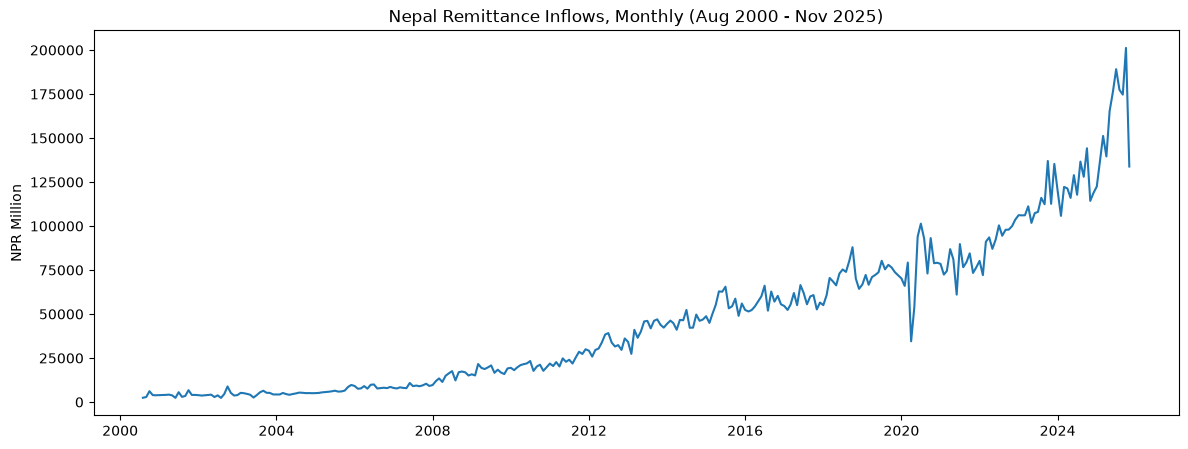

In [10]:
plt.figure(figsize=(14,5))
plt.plot(ts)
plt.title("Nepal Remittance Inflows, Monthly (Aug 2000 - Nov 2025)")
plt.ylabel("NPR Million")
plt.show()

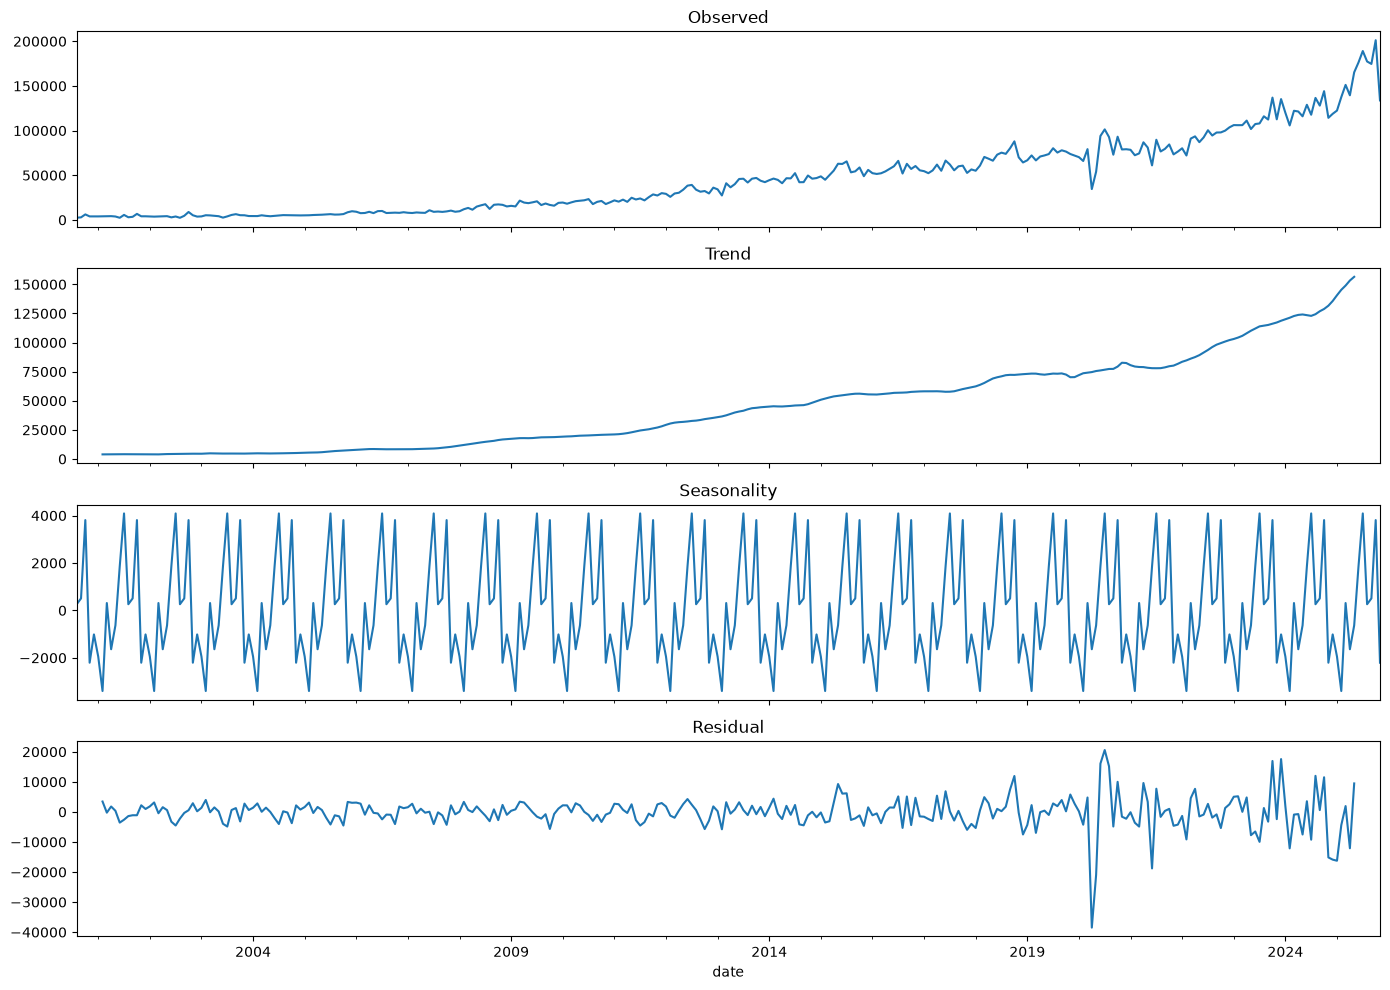

In [13]:

decomposition = seasonal_decompose(ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed")
decomposition.trend.plot(ax=axes[1], title="Trend")
decomposition.seasonal.plot(ax=axes[2], title="Seasonality")
decomposition.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout()
plt.show()

In [15]:

result = adfuller(ts)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("=> Likely stationary (reject the null hypothesis)")
else:
    print("=> Likely NOT stationary (fail to reject the null hypothesis)")

ADF Statistic: 3.6187
p-value: 1.0000
=> Likely NOT stationary (fail to reject the null hypothesis)


C:\Users\ACER\AppData\Local\Temp\ipykernel_12476\2697001300.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(ts)


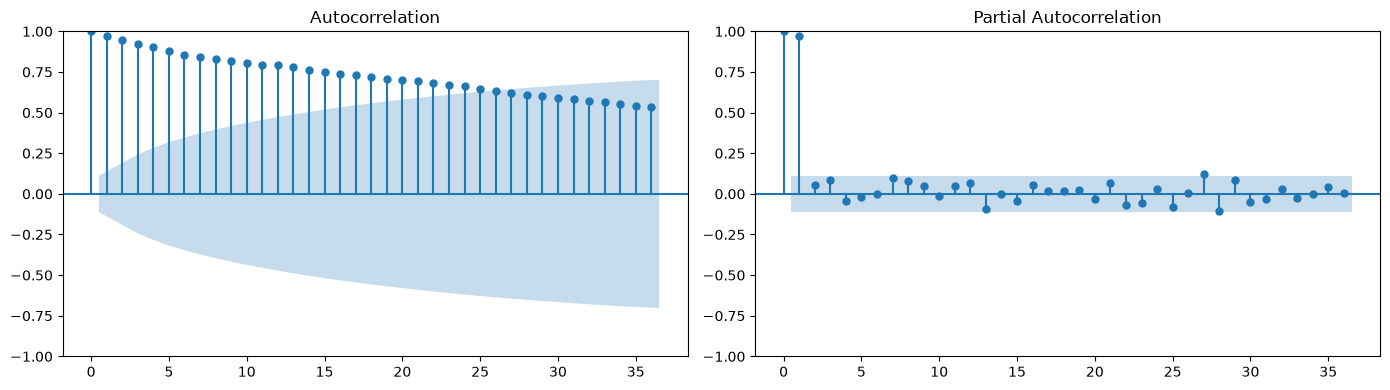

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(ts, lags=36, ax=axes[0])
plot_pacf(ts, lags=36, ax=axes[1])
plt.tight_layout()
plt.show()

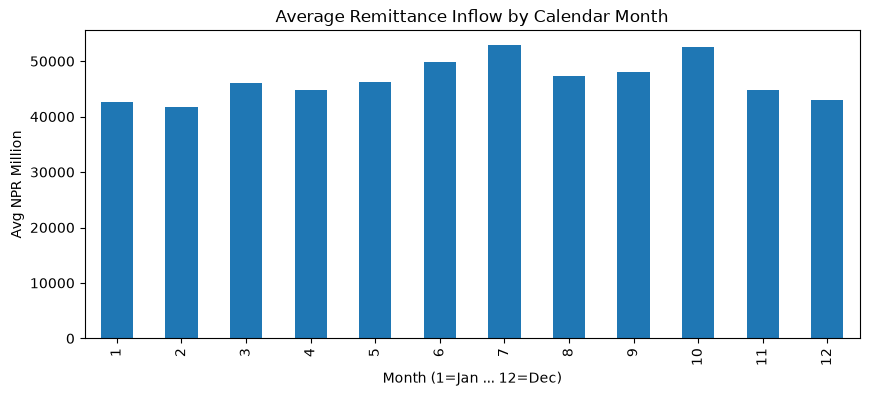

In [17]:
df["month_num"] = df.index.month
monthly_avg = df.groupby("month_num")["remittance_npr_million"].mean()

plt.figure(figsize=(10,4))
monthly_avg.plot(kind="bar")
plt.title("Average Remittance Inflow by Calendar Month")
plt.xlabel("Month (1=Jan ... 12=Dec)")
plt.ylabel("Avg NPR Million")
plt.show()

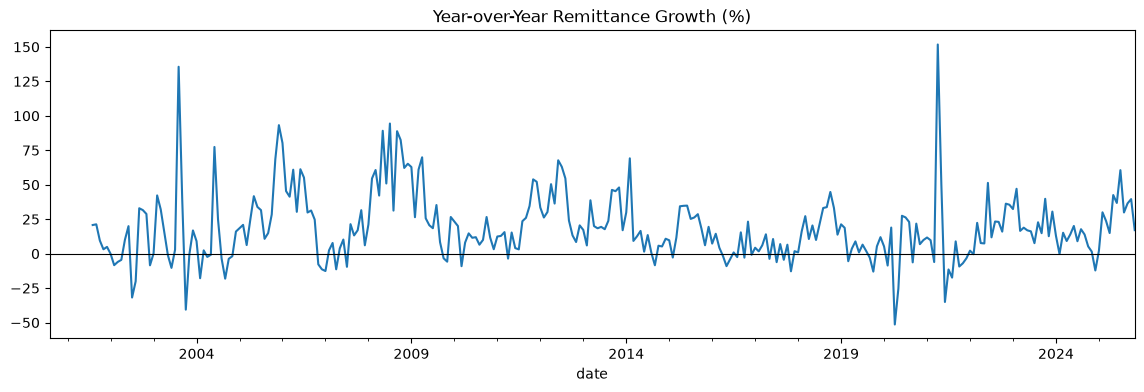

In [18]:
df["yoy_growth_pct"] = df["remittance_npr_million"].pct_change(periods=12) * 100

plt.figure(figsize=(14,4))
df["yoy_growth_pct"].plot()
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Year-over-Year Remittance Growth (%)")
plt.show()